# E3

La variable objetivo es `median_house_value`.

El flujo sera:

- preparar los datos y crear variables derivadas;
- entrenar modelos base de regresion;
- seleccionar hiperparametros usando validacion;
- evaluar una sola vez en test;
- analizar errores por `ocean_proximity` y nivel de ingreso.

## Imports y configuracion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


## Mision 1: Preparacion del conjunto de datos

In [2]:
df_original = pd.read_csv("data/E3_datos.csv")

display(df_original.head())
display(df_original.info())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


None

In [3]:
display(df_original.isna().sum().rename("faltantes"))
display(df_original.describe(include="all"))

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
Name: faltantes, dtype: int64

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9136
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,NaN
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,NaN
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,NaN
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,NaN
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,NaN
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,NaN


La variable objetivo es `median_house_value`, por lo que no se usa para construir las caracteristicas.

`total_bedrooms` tiene valores faltantes. En vez de imputarlos antes de separar los datos, la imputacion se deja dentro del `Pipeline`, para que la mediana se aprenda solo desde entrenamiento.

In [4]:
def add_derived_features(data):
    data = data.copy()
    data["rooms_per_household"] = data["total_rooms"] / data["households"]
    data["bedrooms_per_room"] = data["total_bedrooms"] / data["total_rooms"]
    data["population_per_household"] = data["population"] / data["households"]
    return data

df_features = add_derived_features(df_original)

target = "median_house_value"
X = df_features.drop(columns=[target])
y = df_features[target]

derived_features = ["rooms_per_household", "bedrooms_per_room", "population_per_household"]

print("variables derivadas creadas:")
print(derived_features)
display(X[derived_features].head())

variables derivadas creadas:
['rooms_per_household', 'bedrooms_per_room', 'population_per_household']


,rooms_per_household,bedrooms_per_room,population_per_household
0,6.984127,0.146591,2.555556
1,6.238137,0.155797,2.109842
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467


Las variables derivadas buscan representar caracteristicas a nivel de hogar:

- `rooms_per_household`: habitaciones promedio por hogar.
- `bedrooms_per_room`: proporcion de dormitorios respecto del total de habitaciones.
- `population_per_household`: personas promedio por hogar.

Estas variables suelen ser mas informativas que los totales brutos, porque dos distritos pueden tener escalas muy distintas.

In [5]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("columnas numericas:")
print(numeric_features)
print()
print("columnas categoricas:")
print(categorical_features)

columnas numericas:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

columnas categoricas:
['ocean_proximity']


In [21]:
# value counts de total_bedrooms y total_rooms
display(df_original["total_bedrooms"].value_counts())
display(df_original["total_rooms"].value_counts())
display(df_original["households"].value_counts())

total_bedrooms
280.0     55
331.0     51
345.0     50
393.0     49
343.0     49
          ..
2309.0     1
3521.0     1
3008.0     1
1857.0     1
1052.0     1
Name: count, Length: 1923, dtype: int64

total_rooms
1527.0     18
1613.0     17
1582.0     17
2127.0     16
1471.0     15
           ..
6809.0      1
4224.0      1
4598.0      1
272.0       1
10035.0     1
Name: count, Length: 5926, dtype: int64

households
306.0     57
335.0     56
386.0     56
282.0     55
429.0     54
          ..
2138.0     1
2962.0     1
1767.0     1
1832.0     1
1818.0     1
Name: count, Length: 1815, dtype: int64

Separamos `train`, `validacion` y `test`. El conjunto de test queda guardado hasta el final; no se usa para elegir modelos ni hiperparametros.

In [6]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
)

print(f"Train: {X_train.shape}")
print(f"Validacion: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: (12384, 12)
Validacion: (4128, 12)
Test: (4128, 12)


In [7]:
def make_preprocessor():
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

def make_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", model),
        ]
    )

## Mision 2: Modelo supervisado base

Entrenaremos tres modelos base para tener una comparacion inicial: regresion lineal, arbol de decision y random forest. La comparacion se hara en validacion para mantener test como evaluacion final.

In [8]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }

base_models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(
        max_depth=8,
        random_state=42,
    ),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=80,
        max_depth=12,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
}

base_validation_results = []
fitted_base_models = {}

for name, base_model in base_models.items():
    model = make_pipeline(clone(base_model))
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    fitted_base_models[name] = model
    base_validation_results.append({"modelo": name, **regression_metrics(y_val, val_pred)})

base_validation_results = (pd.DataFrame(base_validation_results).sort_values("RMSE", ascending=True).reset_index(drop=True))

display(base_validation_results)

,modelo,MAE,RMSE,R2
0,RandomForestRegressor,34560.590288,51515.189786,0.806730
1,DecisionTreeRegressor,42807.454474,62808.209468,0.712707
2,LinearRegression,49311.306588,67720.930000,0.666006


In [9]:
selected_model_family = base_validation_results.loc[0, "modelo"]

print(f"familia elegida para explorar hiperparametros: {selected_model_family}")

familia elegida para explorar hiperparametros: RandomForestRegressor


## Mision 3: Seleccion y evaluacion final del modelo

Como `RandomForestRegressor` es el mejor modelo base en validacion, exploraremos distintas configuraciones de sus hiperparametros. La seleccion se hace solo con `train` y `validacion`.

In [10]:
rf_grid = [
    {"n_estimators": 80, "max_depth": 10, "min_samples_leaf": 1},
    {"n_estimators": 80, "max_depth": 14, "min_samples_leaf": 1},
    {"n_estimators": 120, "max_depth": 14, "min_samples_leaf": 2},
    {"n_estimators": 120, "max_depth": 18, "min_samples_leaf": 2},
    {"n_estimators": 160, "max_depth": None, "min_samples_leaf": 2},
]

tuning_results = []

for params in rf_grid:
    rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    model = make_pipeline(rf)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)

    tuning_results.append({**params, **regression_metrics(y_val, val_pred)})

tuning_results = (pd.DataFrame(tuning_results).sort_values("RMSE", ascending=True).reset_index(drop=True))

display(tuning_results)

,n_estimators,max_depth,min_samples_leaf,MAE,RMSE,R2
0,120,18.0,2,33108.821520,50220.400507,0.816324
1,160,NaN,2,33083.011785,50265.808796,0.815991
2,120,14.0,2,33651.647774,50694.864911,0.812837
3,80,14.0,1,33949.791560,50967.224298,0.810820
4,80,10.0,1,36178.104446,52990.402721,0.795503


In [ ]:
best_params = tuning_results.loc[0, ["n_estimators", "max_depth", "min_samples_leaf"]].to_dict()
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["min_samples_leaf"] = int(best_params["min_samples_leaf"])

if pd.isna(best_params["max_depth"]):
    best_params["max_depth"] = None
else:
    best_params["max_depth"] = int(best_params["max_depth"])

print("mejores hiperparametros segun validacion:")
print(best_params)

mejores hiperparametros segun validacion:
{'n_estimators': 120, 'max_depth': 18, 'min_samples_leaf': 2}


Una vez elegida la configuracion, se entrena de nuevo usando `train + validacion` y se evalua una sola vez en test.

In [12]:
final_model = make_pipeline(RandomForestRegressor(**best_params, random_state=42, n_jobs=-1))
final_model.fit(X_train_val, y_train_val)

final_test_pred = final_model.predict(X_test)
final_test_metrics = regression_metrics(y_test, final_test_pred)

display(pd.DataFrame([final_test_metrics], index=["RandomForest final test"]))

,MAE,RMSE,R2
RandomForest final test,31884.152978,49673.165925,0.811706


Para comparar contra un baseline en el mismo test, ajustamos tambien los modelos base con `train + validacion` y los evaluamos una sola vez en test. Esta comparacion se hace despues de haber elegido la configuracion final.

In [13]:
base_test_results = []

for name, base_model in base_models.items():
    model = make_pipeline(clone(base_model))
    model.fit(X_train_val, y_train_val)
    test_pred = model.predict(X_test)
    base_test_results.append({
        "modelo": name,
        **regression_metrics(y_test, test_pred),
    })

comparison_test = pd.concat(
    [
        pd.DataFrame(base_test_results),
        pd.DataFrame([{"modelo": "RandomForestRegressor tuned", **final_test_metrics}]),
    ],
    ignore_index=True,
).sort_values("RMSE", ascending=True).reset_index(drop=True)

display(comparison_test)

,modelo,MAE,RMSE,R2
0,RandomForestRegressor tuned,31884.152978,49673.165925,0.811706
1,RandomForestRegressor,33669.880218,51414.753053,0.798271
2,DecisionTreeRegressor,41938.383688,61933.813261,0.707282
3,LinearRegression,49645.492445,69127.038299,0.635339


## Analisis de errores

In [14]:
error_analysis = X_test.copy()
error_analysis["y_real"] = y_test
error_analysis["y_pred"] = final_test_pred
error_analysis["error"] = error_analysis["y_real"] - error_analysis["y_pred"]
error_analysis["abs_error"] = np.abs(error_analysis["error"])
error_analysis["squared_error"] = error_analysis["error"] ** 2

error_by_ocean = (
    error_analysis
    .groupby("ocean_proximity")
    .agg(
        n=("y_real", "count"),
        valor_real_promedio=("y_real", "mean"),
        prediccion_promedio=("y_pred", "mean"),
        MAE=("abs_error", "mean"),
        RMSE=("squared_error", lambda s: np.sqrt(np.mean(s))),
        sesgo_promedio=("error", "mean"),
        ingreso_promedio=("median_income", "mean"),
    )
    .round(2)
    .sort_values("MAE", ascending=False)
)

display(error_by_ocean)

,n,valor_real_promedio,prediccion_promedio,MAE,RMSE,sesgo_promedio,ingreso_promedio
ocean_proximity,,,,,,,
ISLAND,1,450000.00,344171.51,105828.49,105828.49,105828.49,2.74
NEAR BAY,436,256272.08,258281.44,39074.01,55524.12,-2009.35,4.04
NEAR OCEAN,572,254600.26,249854.74,38907.10,59926.79,4745.52,4.07
<1H OCEAN,1795,237950.25,239879.76,33750.29,50294.52,-1929.51,4.22
INLAND,1324,123390.19,123735.25,23896.57,41090.38,-345.07,3.13


In [15]:
error_analysis["income_group"] = pd.qcut(
    error_analysis["median_income"],
    q=3,
    labels=["ingreso bajo", "ingreso medio", "ingreso alto"],
)

error_by_income = (
    error_analysis
    .groupby("income_group", observed=False)
    .agg(
        n=("y_real", "count"),
        ingreso_promedio=("median_income", "mean"),
        valor_real_promedio=("y_real", "mean"),
        MAE=("abs_error", "mean"),
        RMSE=("squared_error", lambda s: np.sqrt(np.mean(s))),
        sesgo_promedio=("error", "mean"),
    )
    .round(2)
)

display(error_by_income)

,n,ingreso_promedio,valor_real_promedio,MAE,RMSE,sesgo_promedio
income_group,,,,,,
ingreso bajo,1376,2.14,129903.93,24749.51,42605.90,-5.72
ingreso medio,1376,3.50,194538.97,31779.42,49648.34,657.15
ingreso alto,1376,5.85,292058.03,39123.53,55875.30,-2087.59


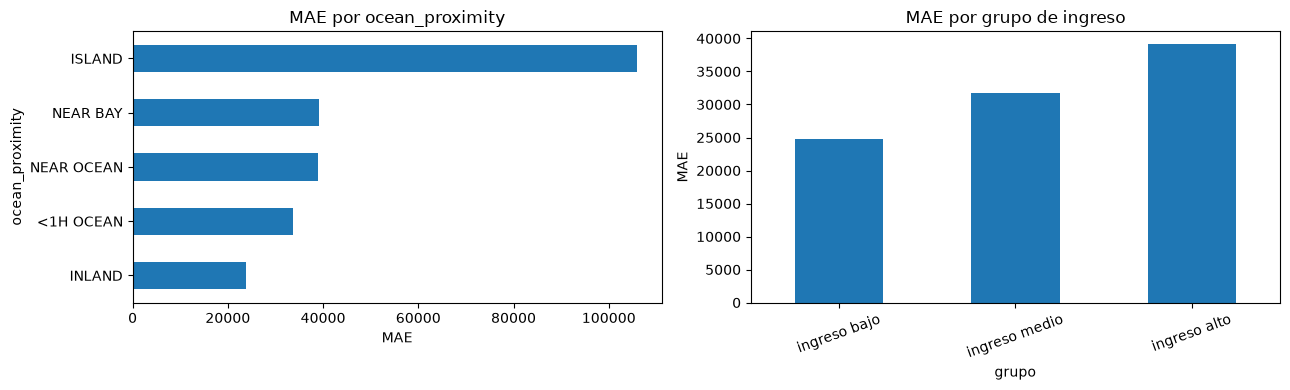

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

error_by_ocean["MAE"].sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("MAE por ocean_proximity")
axes[0].set_xlabel("MAE")

error_by_income["MAE"].plot(kind="bar", ax=axes[1])
axes[1].set_title("MAE por grupo de ingreso")
axes[1].set_xlabel("grupo")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

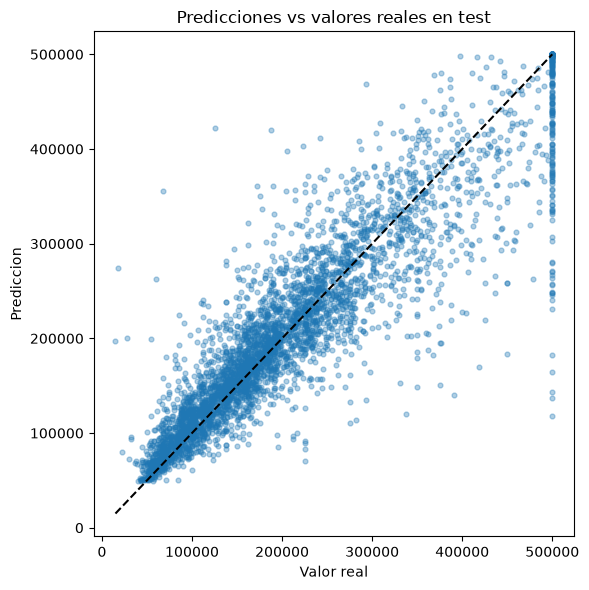

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, final_test_pred, alpha=0.35, s=12)
lims = [
    min(y_test.min(), final_test_pred.min()),
    max(y_test.max(), final_test_pred.max()),
]
plt.plot(lims, lims, linestyle="--", color="black")
plt.xlabel("Valor real")
plt.ylabel("Prediccion")
plt.title("Predicciones vs valores reales en test")
plt.tight_layout()
plt.show()

## Conclusion

El proceso de seleccion por validacion permite mejorar el modelo respecto de las alternativas base mas simples. 

`RandomForestRegressor` obtiene el mejor rendimiento porque captura relaciones no lineales entre ubicacion, ingreso, escala del distrito y valor habitacional.

En el analisis de errores se observan diferencias entre categorias de `ocean_proximity` y entre niveles de ingreso. 

En particular, los distritos con mayores ingresos y valores de vivienda suelen ser mas dificiles de predecir, probablemente porque el precio esta influido por factores no presentes en la base, como calidad especifica del barrio, acceso a servicios, colegios, seguridad o restricciones de oferta.

Una limitacion importante es que el modelo usa informacion agregada por distrito, no datos a nivel de vivienda individual. Ademas, aunque `longitude` y `latitude` ayudan a representar ubicacion, no capturan por completo la estructura territorial real de California.